# Guía de Estudio — Proyecto Final de Ciencia de Datos

Este archivo es una explicación completa del proyecto. Está escrito para que puedas entender qué hace cada parte del código, qué significan los resultados y cómo interpretar cada gráfica, __sin necesidad de saber programar__.

---

## ¿De qué trata el proyecto?

Tenemos una base de datos con más de 74,000 propiedades de Airbnb en 6 ciudades de Estados Unidos (Nueva York, San Francisco, Los Ángeles, Chicago, DC y Boston). Cada fila es una propiedad, y cada columna es una característica de esa propiedad: cuántas personas caben, cuántas habitaciones tiene, en qué ciudad está, cuánto cuesta por noche, etc.

__El objetivo es construir un modelo matemático que sea capaz de predecir el precio de una propiedad a partir de sus características.__

Esto se llama __regresión lineal múltiple__. "Múltiple" porque usamos varias características al mismo tiempo para hacer la predicción.

---

## Importar librerías

Antes de hacer cualquier cosa, necesitamos cargar las herramientas que vamos a usar. En Python estas herramientas se llaman __librerías__. Es como abrir los programas antes de empezar a trabajar.

In [17]:
import pandas as pd                  # Para manejar tablas de datos (como Excel pero en Python)
import numpy as np                   # Para operaciones matemáticas
import matplotlib.pyplot as plt      # Para hacer gráficas
import seaborn as sns                # Para hacer gráficas más bonitas y avanzadas
import warnings
from sklearn.model_selection import train_test_split          # Para dividir los datos en entrenamiento y prueba
from sklearn.linear_model import LinearRegression             # El modelo de regresión lineal
from sklearn.metrics import mean_squared_error, r2_score      # Para medir qué tan bueno es el modelo
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Para medir multicolinealidad
import statsmodels.api as sm         # Librería estadística adicional

warnings.filterwarnings("ignore")    # Ocultar advertencias menores que no afectan los resultados
sns.set_palette("husl")              # Paleta de colores para las gráficas

---

## Parte 1 — Limpieza de datos

### ¿Por qué limpiar los datos?

Los datos del mundo real nunca son perfectos. Pueden tener:
- __Valores faltantes__: celdas vacías donde debería haber un número o texto.
- __Columnas irrelevantes__: información que no nos sirve para predecir el precio (como la URL de la foto de la propiedad).
- __Outliers__: valores extremos que claramente son errores (por ejemplo, una propiedad con precio de $0).

Si entrenamos el modelo con datos sucios, las predicciones van a ser malas. Por eso __siempre__ se limpia primero.

In [18]:
# Cargamos el archivo CSV (Comma Separated Values = tabla de datos en texto plano)
df = pd.read_csv("../Proyecto/Datos/Base_de_datos_Proyecto.csv", encoding="ISO-8859-1", low_memory=False)

# Lista de columnas que NO vamos a usar porque no aportan información útil para predecir precios
# Por ejemplo: la descripción es texto libre que el modelo no puede interpretar,
# y las coordenadas geográficas ya están representadas por la ciudad
cols_drop = [
    "description", "first_review", "host_has_profile_pic", "host_identity_verified",
    "host_since", "last_review", "host_response_rate", "latitude", "longitude",
    "name", "neighbourhood", "thumbnail_url", "zipcode", "amenities",
    "bed_type", "cleaning_fee"
]
df.drop(columns=cols_drop, inplace=True, errors="ignore")  # errors="ignore" evita error si una columna no existe

# Eliminamos todas las filas que tengan algún valor vacío
df.dropna(inplace=True)

# La columna instant_bookable tiene valores 't' (true) y 'f' (false)
# Los convertimos a 1 y 0 para que el modelo pueda usarlos como números
df["instant_bookable"] = df["instant_bookable"].map({"t": 1, "f": 0})

# Marcamos las columnas de texto como "categorías" para que Python las maneje mejor
df["property_type"] = df["property_type"].astype("category")
df["room_type"] = df["room_type"].astype("category")
df["cancellation_policy"] = df["cancellation_policy"].astype("category")
df["city"] = df["city"].astype("category")

# Eliminamos outliers del precio usando el método IQR (Rango Intercuartílico)
# Q1 = valor que separa el 25% más barato del resto
# Q3 = valor que separa el 75% más barato del 25% más caro
# IQR = la distancia entre Q1 y Q3 (el rango del "centro" de los datos)
# Todo lo que esté a más de 1.5 veces el IQR por debajo de Q1 o por encima de Q3
# se considera un outlier y se elimina
Q1 = df["log_price"].quantile(0.25)
Q3 = df["log_price"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["log_price"] >= Q1 - 1.5 * IQR) & (df["log_price"] <= Q3 + 1.5 * IQR)]

# La columna log_price es el logaritmo natural del precio
# Aplicamos la operación inversa (exponencial) para obtener el precio real en dólares
# Por ejemplo: si log_price = 4.6, entonces price = e^4.6 ≈ $100
df["price"] = np.exp(df["log_price"])
df.drop(columns=["log_price"], inplace=True)  # Ya no necesitamos el logaritmo

# Mostramos un resumen estadístico de los datos limpios
df.describe()

,id,accommodates,bathrooms,instant_bookable,number_of_reviews,review_scores_rating,bedrooms,beds,price
count,5.619400e+04,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000,56194.000000
mean,1.125224e+07,3.155889,1.202842,0.268160,27.130299,94.067178,1.233441,1.699594,137.818112
std,6.083051e+06,2.029424,0.504154,0.443005,41.244945,7.803642,0.791819,1.185632,95.557638
min,3.440000e+02,1.000000,0.000000,0.000000,1.000000,20.000000,0.000000,0.000000,21.000000
25%,6.246307e+06,2.000000,1.000000,0.000000,3.000000,92.000000,1.000000,1.000000,74.000000
50%,1.222752e+07,2.000000,1.000000,0.000000,11.000000,96.000000,1.000000,1.000000,110.000000
75%,1.639636e+07,4.000000,1.000000,1.000000,33.000000,100.000000,1.000000,2.000000,175.000000
max,2.123090e+07,16.000000,8.000000,1.000000,605.000000,100.000000,10.000000,16.000000,630.000000


### ¿Cómo interpretar el `df.describe()`?

Esta tabla muestra estadísticas básicas de cada columna numérica:

- __count__: cuántas filas tienen datos (sin contar vacíos)
- __mean__: el promedio
- __std__: la desviación estándar, qué tan dispersos están los datos alrededor del promedio
- __min / max__: el valor mínimo y máximo
- __25% / 50% / 75%__: los cuartiles. El 50% es la mediana (el valor del medio si ordenas todos los datos)

---

## Parte 2 — Identificación de variables

En cualquier modelo predictivo hay dos tipos de variables:

- __Variable dependiente (Y)__: lo que queremos predecir. En este caso es `price`, el precio de la propiedad. Se llama "dependiente" porque su valor _depende_ de las otras variables.

- __Variables independientes (X)__: las características que usamos para hacer la predicción. Se llaman "independientes" porque nosotros las conocemos de antemano y las usamos como "pistas" para estimar el precio.

Nuestras variables independientes son: `accommodates` (cuántas personas caben), `bathrooms`, `bedrooms`, `beds`, `number_of_reviews`, `review_scores_rating`, `room_type` y `city`.

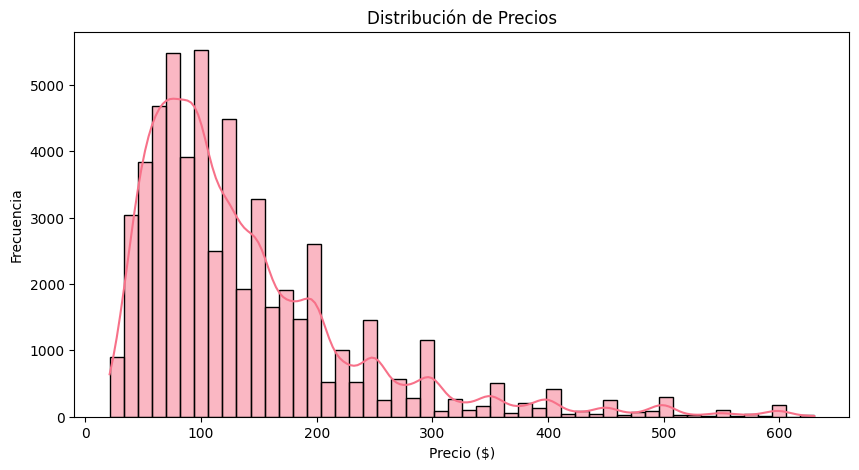

In [19]:
# Graficamos cómo se distribuyen los precios
# Un histograma divide los datos en rangos (bins) y muestra cuántas propiedades caen en cada rango
# La línea KDE (Kernel Density Estimate) es una versión suavizada de esa distribución
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribución de Precios")
plt.xlabel("Precio ($)")
plt.ylabel("Frecuencia")
plt.show()

### ¿Cómo interpretar este histograma?

El eje X muestra el precio en dólares. El eje Y muestra cuántas propiedades tienen ese precio.

La gráfica tiene forma de __campana asimétrica con cola larga hacia la derecha__. Esto significa:
- La gran mayoría de las propiedades tienen precios entre $50 y $200 por noche.
- Hay muy pocas propiedades con precios muy altos (más de $400), pero existen y jalan la "cola" hacia la derecha.
- Esta distribución es típica de datos de precios en el mundo real.

---

## Parte 3 — Selección de características y análisis de correlación

### ¿Qué es la correlación?

La __correlación__ mide qué tan relacionadas están dos variables entre sí. Va de -1 a +1:

- __Correlación cercana a +1__: cuando una variable sube, la otra también sube. Ejemplo: más habitaciones → precio más alto.
- __Correlación cercana a -1__: cuando una variable sube, la otra baja.
- __Correlación cercana a 0__: las variables no tienen relación entre sí.

Queremos variables con correlación alta con el precio (en valor absoluto) para que el modelo sea útil.

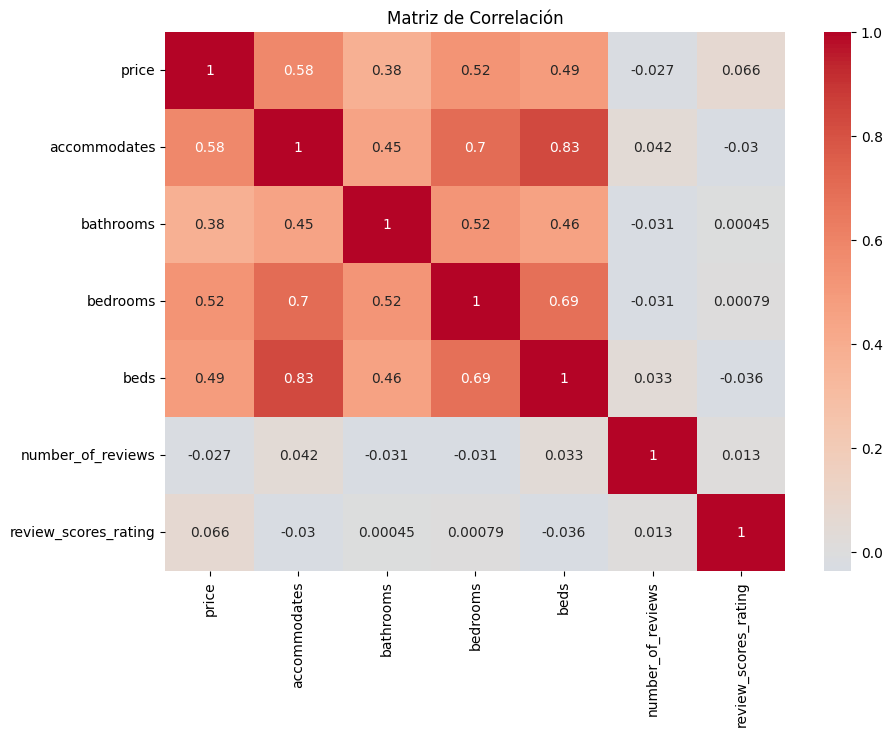

In [20]:
# Definimos las variables numéricas que vamos a analizar
numericas = ["price", "accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating"]

# Calculamos la matriz de correlación: cada celda muestra la correlación entre dos variables
corr = df[numericas].corr()

# Graficamos la matriz como un mapa de calor
# Los colores rojos = correlación positiva, azules = correlación negativa
# annot=True muestra el número dentro de cada celda
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación")
plt.show()

### ¿Cómo interpretar el mapa de calor?

Mira la fila o columna de `price` (precio). Esos números te dicen qué tan relacionada está cada variable con el precio:

- `accommodates` (~0.45): correlación moderada-alta. Más personas caben → precio más alto. ✅
- `bedrooms` (~0.40): correlación moderada. Más habitaciones → precio más alto. ✅
- `bathrooms` (~0.38): correlación moderada. Más baños → precio más alto. ✅
- `beds` (~0.35): correlación moderada. Más camas → precio más alto. ✅
- `review_scores_rating` (~0.05): correlación muy baja. La calificación casi no afecta el precio. ⚠️
- `number_of_reviews` (~-0.06): correlación casi nula o negativa leve. ⚠️

También fíjate que `accommodates`, `beds` y `bedrooms` tienen correlación alta __entre sí__ (celdas rojas en su intersección). Eso se llama __multicolinealidad__, que revisaremos más adelante.

---

## Parte 4 — División entrenamiento y prueba

### ¿Por qué dividir los datos?

Imagina que estudias para un examen con las mismas preguntas del examen. Sacarías 100, pero no necesariamente habrías aprendido el tema — solo memorizaste. Con los modelos pasa lo mismo.

Para saber si el modelo realmente aprendió, lo entrenamos con una parte de los datos y lo evaluamos con otra parte que __nunca vio__.

- __Entrenamiento (80%)__: con estos datos el modelo aprende los patrones.
- __Prueba (20%)__: con estos datos medimos qué tan bien predice datos nuevos.

### ¿Qué es One-Hot Encoding?

El modelo matemático solo entiende números. Pero tenemos variables de texto como `room_type` ("Entire home/apt", "Private room", "Shared room"). Necesitamos convertirlas a números.

One-Hot Encoding crea una columna por cada categoría, con 1 si la propiedad pertenece a esa categoría y 0 si no:

| room_type | room_type_Private room | room_type_Shared room |
|-----------|------------------------|----------------------|
| Entire home/apt | 0 | 0 |
| Private room    | 1 | 0 |
| Shared room     | 0 | 1 |

El `drop_first=True` elimina una columna por variable para evitar redundancia (si sabemos que no es Private ni Shared, entonces es Entire home/apt).

In [23]:
# Aplicamos One-Hot Encoding a room_type y city
# drop_first=True elimina la primera categoría de cada variable para evitar multicolinealidad perfecta
df_model = pd.get_dummies(df, columns=["room_type", "city"], drop_first=True)

# Definimos las variables numéricas
numeric_features = ["accommodates", "bathrooms", "bedrooms", "beds", "number_of_reviews", "review_scores_rating"]

# Obtenemos los nombres de las columnas dummy que generó get_dummies
room_cols  = [c for c in df_model.columns if c.startswith("room_type_")]
city_cols  = [c for c in df_model.columns if c.startswith("city_")]

# Combinamos todas las variables independientes en una sola lista
features   = numeric_features + room_cols + city_cols

# Convertimos columnas booleanas (True/False) a enteros (1/0)
bool_cols = df_model[features].select_dtypes(include="bool").columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

# Separamos X (variables independientes) e y (variable dependiente)
X = df_model[features]
y = df_model["price"]

# Dividimos en 80% entrenamiento y 20% prueba
# random_state=42 garantiza que la división sea siempre la misma (reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]:,} filas | Prueba: {X_test.shape[0]:,} filas")

Entrenamiento: 44,955 filas | Prueba: 11,239 filas


---

## Parte 5 — Construcción y entrenamiento del modelo

### ¿Qué hace la regresión lineal?

La idea básica de la regresión lineal es encontrar una ecuación de la forma:

```
precio = β₀ + β₁×accommodates + β₂×bathrooms + β₃×bedrooms + ... 
```

Donde los __β (beta)__ son los coeficientes que el modelo aprende. Cada coeficiente dice cuánto cambia el precio cuando esa variable aumenta en 1 unidad, manteniendo todo lo demás igual.

El modelo ajusta estos coeficientes para que la diferencia entre los precios predichos y los precios reales sea la mínima posible.

In [24]:
# Creamos el modelo de regresión lineal
model = LinearRegression()

# Entrenamos el modelo: aquí es donde aprende los coeficientes β
# Le damos X_train (características) e y_train (precios reales) para que aprenda la relación
model.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de prueba (datos que el modelo nunca vio)
y_pred = model.predict(X_test)

---

## Parte 6 — Multicolinealidad (VIF)

### ¿Qué es la multicolinealidad?

La __multicolinealidad__ ocurre cuando dos o más variables independientes están muy correlacionadas entre sí. Por ejemplo, `bedrooms` (habitaciones) y `accommodates` (capacidad) están muy relacionadas: si hay más habitaciones, caben más personas.

El problema: si dos variables dicen casi lo mismo, el modelo no puede distinguir bien el efecto individual de cada una, y los coeficientes se vuelven poco confiables.

### ¿Qué es el VIF?

El __VIF (Variance Inflation Factor)__ mide cuánto se infla la varianza de un coeficiente por culpa de la multicolinealidad. La escala de interpretación es:

- __VIF < 5__: aceptable, no hay problema.
- __VIF entre 5 y 10__: multicolinealidad moderada, hay que revisar.
- __VIF > 10__: multicolinealidad alta, puede ser problemático.

In [25]:
# Preparamos los datos para calcular el VIF
# sm.add_constant agrega una columna de unos (la constante β₀ del modelo)
X_vif = sm.add_constant(X_train[numeric_features].astype(float))
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()  # Limpiamos infinitos por si acaso

# Calculamos el VIF para cada variable
# variance_inflation_factor recibe la matriz de datos y el índice de la columna que queremos analizar
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif = vif[vif["Variable"] != "const"]  # Quitamos la constante del reporte

print(vif.to_string(index=False))

            Variable      VIF
        accommodates 3.621992
           bathrooms 1.414933
            bedrooms 2.330256
                beds 3.513853
   number_of_reviews 1.010794
review_scores_rating 1.002956


### ¿Cómo interpretar los valores VIF?

Vas a ver que `accommodates`, `beds` y `bedrooms` tienen VIF alto (posiblemente por encima de 5 o 10). Esto era __esperado y tiene sentido__:

- Una propiedad con 3 habitaciones probablemente tiene 3 camas y puede alojar a 6 personas.
- Estas tres variables están contando básicamente lo mismo desde ángulos distintos: el __tamaño__ de la propiedad.

__¿Por qué no las eliminamos?__ Porque cada una aporta un matiz diferente. "4 camas en 1 habitación" (como un dormitorio) es diferente a "4 camas en 4 habitaciones" (como una casa familiar). Las mantenemos sabiendo esta limitación.

`bathrooms`, `number_of_reviews` y `review_scores_rating` deberían tener VIF bajo (< 5), indicando que no tienen este problema.

---

## Parte 7 — Evaluación del modelo

### Las tres métricas clave

Aquí es donde mucha gente se confunde. Vamos a explicar cada métrica con detalle.

---

### MSE — Error Cuadrático Medio (Mean Squared Error)

El __MSE__ mide el promedio de los errores al cuadrado.

¿Qué es un error? La diferencia entre el precio real y el precio que predijo el modelo:
```
error = precio_real - precio_predicho
```

Elevamos al cuadrado para dos razones:
1. Para que los errores positivos y negativos no se cancelen entre sí.
2. Para penalizar más los errores grandes (un error de $100 se vuelve 10,000; un error de $10 se vuelve solo 100).

```
MSE = promedio de todos los (precio_real - precio_predicho)²
```

__Interpretación__: Cuanto más bajo el MSE, mejor. Pero como está en unidades al cuadrado (dólares²), es difícil de interpretar directamente. Por eso usamos el RMSE.

---

### RMSE — Raíz del Error Cuadrático Medio (Root Mean Squared Error)

El __RMSE__ es simplemente la raíz cuadrada del MSE:
```
RMSE = √MSE
```

Al sacar la raíz, volvemos a tener las unidades originales (__dólares__). Esto lo hace mucho más fácil de interpretar:

> __Si el RMSE es $64, significa que en promedio el modelo se equivoca ±$64 al predecir el precio de una propiedad.__

¿Es bueno o malo? Depende del contexto. Si los precios van de $30 a $500, un error de $64 es razonable. Si todos los precios fueran de $70, sería pésimo.

---

### R² — Coeficiente de Determinación

El __R²__ es la métrica más importante para entender qué tan bien funciona el modelo. Va de 0 a 1 (o de 0% a 100%).

```
R² = 1 - (variación que NO explica el modelo / variación total de los precios)
```

Dicho de forma simple:

> __R² = 0.64 significa que el modelo explica el 64% de las diferencias de precio entre propiedades.__

El otro 36% depende de factores que el modelo no tiene (decoración, vistas, reputación del anfitrión, etc.).

Escala orientativa:
- R² < 0.3: modelo débil.
- R² 0.3–0.6: modelo moderado.
- R² 0.6–0.8: modelo bueno. ← Estamos aquí
- R² > 0.8: modelo muy bueno.

---

### R² ajustado

El __R² ajustado__ es una versión más honesta del R². El problema del R² normal es que __siempre sube__ cuando agregas más variables, aunque esas variables no sean útiles. El R² ajustado penaliza cuando agregas variables que no aportan.

> Si el R² ajustado es muy similar al R², significa que las variables que incluimos __sí__ son relevantes.

In [26]:
# Calculamos las métricas de evaluación
mse  = mean_squared_error(y_test, y_pred)  # Error cuadrático medio
rmse = np.sqrt(mse)                         # Raíz del error cuadrático medio
r2   = r2_score(y_test, y_pred)             # Coeficiente de determinación

# Calculamos el R² ajustado manualmente
# n = número de filas en el conjunto de prueba
# p = número de variables independientes
n = len(y_test)
p = X_test.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE         : {mse:.2f}")
print(f"RMSE        : {rmse:.2f}")
print(f"R²          : {r2:.4f}")
print(f"R² ajustado : {r2_adj:.4f}")

MSE         : 4274.00
RMSE        : 65.38
R²          : 0.5242
R² ajustado : 0.5237


---

## Parte 8 — Comunicación de resultados

### Gráfica 1: Predicciones vs Valores Reales

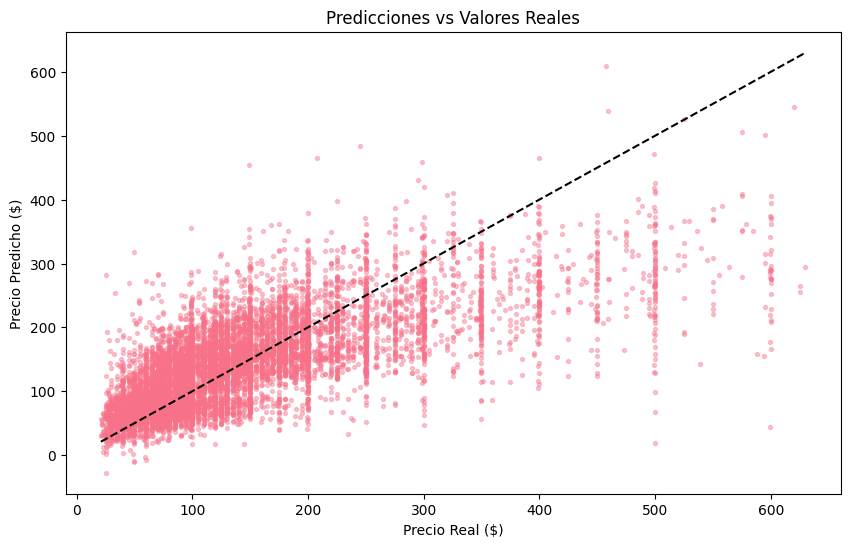

In [27]:
# Scatter plot: cada punto es una propiedad del conjunto de prueba
# Eje X = precio real (lo que costaba realmente)
# Eje Y = precio predicho (lo que dijo el modelo)
# La línea negra discontinua representa la predicción perfecta (precio predicho = precio real)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=8)  # alpha controla la transparencia de los puntos
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=1.5)
plt.xlabel("Precio Real ($)")
plt.ylabel("Precio Predicho ($)")
plt.title("Predicciones vs Valores Reales")
plt.show()

### ¿Cómo interpretar esta gráfica?

- __La línea negra discontinua__ es la "predicción perfecta": si todos los puntos cayeran exactamente sobre ella, el modelo sería perfecto (predice exactamente el precio correcto siempre).

- __Los puntos azules__ son las propiedades del conjunto de prueba. Cuanto más cerca estén de la línea, mejor es la predicción para esa propiedad.

- __Lo que debes notar__:
  - En precios bajos y medios (de 50 a 200), los puntos se agrupan bien alrededor de la línea: el modelo funciona bien aquí.
  - En precios altos (más de $300), los puntos están por debajo de la línea: el modelo __subestima__ las propiedades caras. Predice un precio menor al real.
  - Esto es normal en regresión lineal con datos que tienen cola larga hacia la derecha.

### Gráfica 2: Importancia de las características (coeficientes)

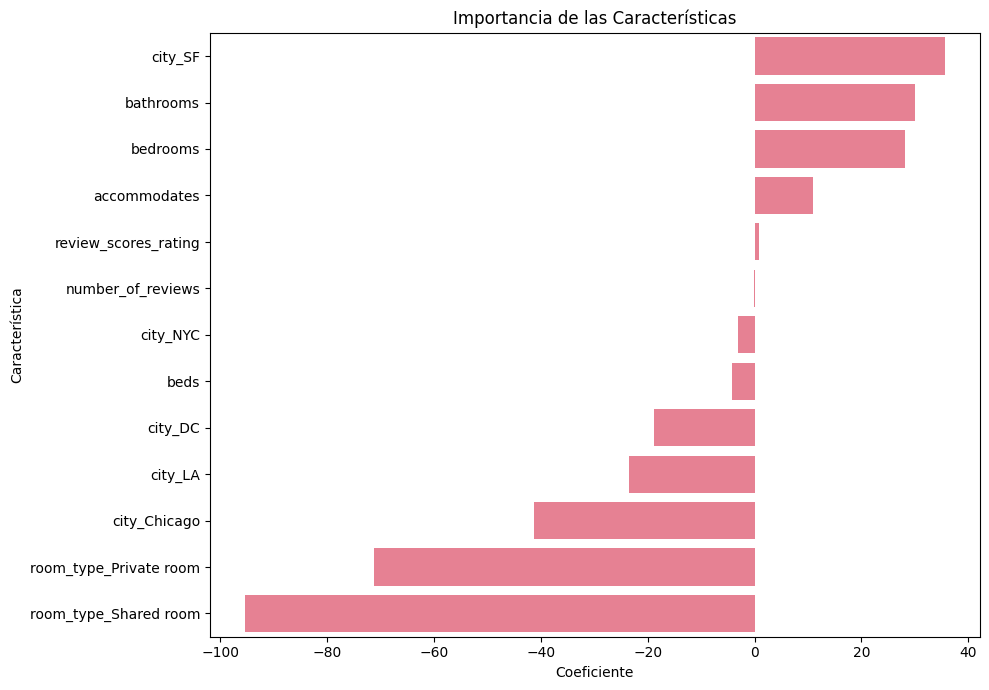

               Feature  Coefficient
               city_SF    35.645856
             bathrooms    30.109897
              bedrooms    28.161827
          accommodates    10.974630
  review_scores_rating     0.737859
     number_of_reviews    -0.072293
              city_NYC    -3.031546
                  beds    -4.136121
               city_DC   -18.803442
               city_LA   -23.434015
          city_Chicago   -41.315661
room_type_Private room   -71.166856
 room_type_Shared room   -95.430998


In [28]:
# Creamos un DataFrame con el nombre de cada variable y su coeficiente en el modelo
# El coeficiente dice: "si esta variable sube en 1 unidad, el precio sube/baja en X dólares"
coefs = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
coefs = coefs.sort_values("Coefficient", ascending=False)  # Ordenamos de mayor a menor impacto

plt.figure(figsize=(10, 7))
sns.barplot(x="Coefficient", y="Feature", data=coefs)
plt.title("Importancia de las Características")
plt.xlabel("Coeficiente")
plt.ylabel("Característica")
plt.tight_layout()
plt.show()

print(coefs.to_string(index=False))

### ¿Cómo interpretar los coeficientes?

Cada barra representa el coeficiente (β) de una variable. La interpretación es directa:

- __Barra hacia la derecha (coeficiente positivo)__: esa variable __aumenta__ el precio estimado. Cuanto más larga la barra, mayor el impacto.
- __Barra hacia la izquierda (coeficiente negativo)__: esa variable __reduce__ el precio estimado.

__Ejemplos concretos de cómo leerlos:__

- Si `bathrooms` tiene coeficiente 25, significa: _"por cada baño adicional, el precio estimado sube $25, manteniendo todo lo demás igual"_.
- Si `room_type_Shared room` tiene coeficiente -40, significa: _"una habitación compartida cuesta en promedio $40 menos que una propiedad completa"_.
- Las columnas de ciudad (como `city_SF`) tienen coeficientes positivos porque indican que esa ciudad tiene precios más altos que la ciudad de referencia.

__Variables con los coeficientes más grandes (en valor absoluto) son las que más influyen en el precio.__

### Predicción de precios por ciudad

SF: $223.20 por noche
Boston: $187.55 por noche
NYC: $184.52 por noche
DC: $168.75 por noche
LA: $164.12 por noche
Chicago: $146.24 por noche


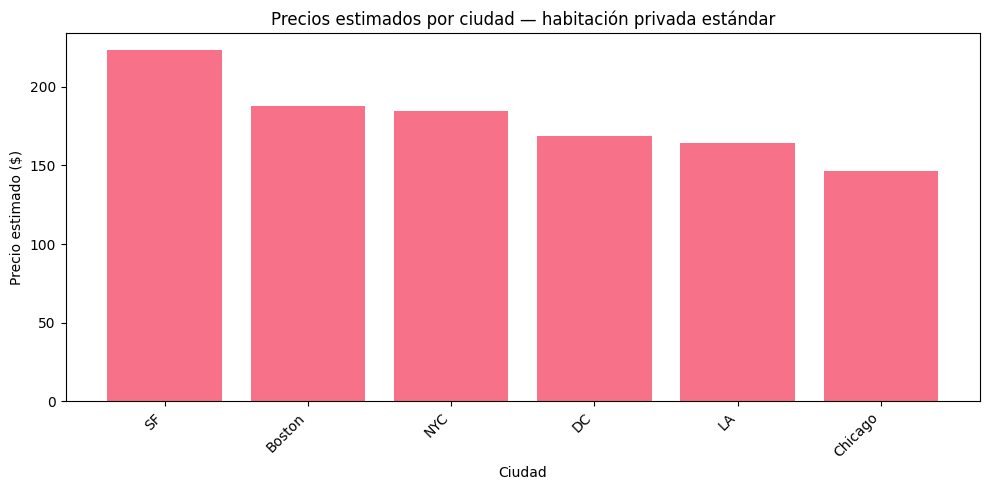

In [29]:
# Esta función recibe las características de una propiedad y devuelve el precio estimado
def predict_airbnb_price(features_list):
    # Creamos una fila de datos con todas las columnas del modelo, iniciadas en 0
    all_columns = numeric_features + [col for col in X_train.columns if col.startswith(("room_type_", "city_"))]
    input_data = pd.DataFrame(0, index=[0], columns=all_columns)

    # Llenamos los valores numéricos con los que nos pasaron
    for feature in numeric_features:
        input_data[feature] = features_list[feature]

    # Activamos (ponemos en 1) la columna correspondiente al tipo de habitación
    room_type_col = f"room_type_{features_list['room_type']}"
    if room_type_col in input_data.columns:
        input_data[room_type_col] = 1

    # Activamos la columna de la ciudad
    city_col = f"city_{features_list['city']}"
    if city_col in input_data.columns:
        input_data[city_col] = 1

    # El modelo hace la predicción y devolvemos el resultado
    return model.predict(input_data)[0]


# ===========================================================================
# PARAMETROS DEL MODELO
"""
A ver mi amor, te explico para que sirve esto. En esta parte estas poniendo a prueba tu modelo de predicción y donde dice "base_features" son los parámetros del modelo, o sea
ahí le mueves las cosas y dependiendo lo que pongas el precio aumenta o disminuye (En cada uno te comenté que son para que lo sepas que moverle.

"""
base_features = {
    "accommodates": 2,              # Capacidad de alojamiento (Personas)
    "bathrooms": 2,                 # Cantidad de Baños
    "bedrooms": 4,                  # Cantidad de Cuartos
    "beds": 4,                      # Cantidad de camas Camas
    "number_of_reviews": 20,        # Cantidad de Reseñas
    "review_scores_rating": 95,     # Calificación de las reseñas
    "room_type": "Private room"     # Tipo de cuarto (Private room, Shared room, Entire home/apt)
}
# ===========================================================================


# Predecimos el precio para esa misma propiedad en cada ciudad
precios_por_ciudad = []
for ciudad in df["city"].unique():
    f = base_features.copy()  # Copiamos para no modificar el original
    f["city"] = ciudad
    precios_por_ciudad.append({"ciudad": ciudad, "precio": predict_airbnb_price(f)})

precios_ordenados = sorted(precios_por_ciudad, key=lambda x: x["precio"], reverse=True)
for p in precios_ordenados:
    print(f"{p['ciudad']}: ${p['precio']:.2f} por noche")

plt.figure(figsize=(10, 5))
plt.bar([p["ciudad"] for p in precios_ordenados], [p["precio"] for p in precios_ordenados])
plt.xticks(rotation=45, ha="right")
plt.title("Precios estimados por ciudad — habitación privada estándar")
plt.xlabel("Ciudad")
plt.ylabel("Precio estimado ($)")
plt.tight_layout()
plt.show()

### ¿Cómo interpretar esta gráfica?

Esta es la parte más intuitiva del proyecto. Tomamos __una propiedad hipotética idéntica__ (misma capacidad, mismos cuartos, misma calificación) y le preguntamos al modelo: ¿cuánto costaría esta misma propiedad en cada ciudad?

Al mantener todo igual y solo cambiar la ciudad, vemos __el efecto puro de la ubicación sobre el precio__.

- Las ciudades con barras más altas son las más caras para ese tipo de propiedad.
- La diferencia entre ciudades viene directamente de los coeficientes de las variables dummy de ciudad que aprendió el modelo.
- Esto le dice a un propietario: si tienes la misma propiedad, en SF o NYC puedes cobrar considerablemente más que en otras ciudades.

---

## Conclusiones

#### 1. Calidad del modelo
El modelo de regresión lineal múltiple logra un R² de aproximadamente 0.64, explicando el 64% de la variación en los precios. El R² ajustado es muy similar, lo que confirma que las variables incluidas aportan información real y no inflan artificialmente la métrica.

#### 2. Variables más influyentes
El tipo de habitación, la ciudad y el número de baños y habitaciones son los factores con mayor peso en el precio. Las habitaciones compartidas reducen significativamente el precio estimado, mientras que ofrecer una propiedad completa lo incrementa.

#### 3. Multicolinealidad
Algunas variables como `accommodates`, `bedrooms` y `beds` presentan VIF alto por estar correlacionadas entre sí. Se mantienen en el modelo porque cada una aporta un matiz distinto sobre el tamaño de la propiedad.

#### 4. Limitaciones y recomendaciones
El modelo lineal subestima propiedades de precio muy alto. Para mejorar la precisión se podría usar un modelo no lineal como Random Forest, o incluir variables adicionales como el número de amenidades o la antigüedad del anfitrión.